In [2]:
# to import scripts from another folder, use sys, os, and path.append
import sys
import os
sys.path.append(r"C:\Users\HAOXUAN YIN\Desktop\Master Project Analysis\code\Brant_Analysis")

import importlib
import pandas as pd
import preprocess_behav2p as preprocess
import analysis_functions as af
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
import os
import pickle
from matplotlib.animation import FuncAnimation
from io_utils import save_pickle, load_pickle
import init_vars as iv
import visualize as viz
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter1d , uniform_filter1d
def smooth(x, sigma=2):
    return gaussian_filter1d(x, sigma)
from matplotlib.backends.backend_pdf import PdfPages

d:\anaconda\envs\preprocessData\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
data = load_pickle(r"Y:\public\projects\SaEl_20220201_VIP\2pdata\LC\LCax_brant")

In [5]:
importlib.reload(af)
importlib.reload(iv)
colors = sns.color_palette("mako", 13)
poststim_frames = slice(23,33) 
prestim_frames = slice(10,15)
max_tr, thres = 5, 0.4
blo1trials, blo2trials, sig_cells = {}, {}, {}
ani_range = [0]

for ani in ani_range:
    unpred_gratings = iv.get_unpred_grats(data[ani])
    blo1, blo2 = iv.init_trial_blocks(unpred_gratings, max_tr=max_tr)
    btri = iv.sparse_pred_trials(data[ani], unpred_gratings, max_tr, method='simple')
    data[ani]['pred_trials'] = np.setdiff1d(np.arange(data[ani]['activity']['gr_1'].shape[1]),np.concatenate(list(unpred_gratings.values())))
    if len(btri) > 0:
        blo1['gr_2'] = btri
        blo2['gr_2'] = btri
    if "X0" in blo1:
        blo1['gr_1'] = blo1["X0"]
        blo2['gr_1'] = blo2["X0"]
    blo1trials[ani], blo2trials[ani] = blo1, blo2
    mapping = {'gr_1': 'gr_1', 'gr_2': 'gr_2','X0': 'gr_2'}
    sig_cells[ani] = iv.get_sig_cells(data[ani], blo1, blo2, mapping, thres, prestim_frames, poststim_frames,method='thresh')

In [6]:
def plot_heatmaps(data, ani_range, conditions, poststim_frames, max_tri=15,figsize=(12,6), vmin=-1, vmax=1, sort_by='self',label='axonal boutons'):
    condition_data = []
    for cond in conditions:
        cond_list = []
        for ani in ani_range:
            if cond['type'] == 'predicted':
                trials = iv.sparse_pred_trials(data[ani], data[ani]['unpred_trials'], max_tri, method='simple')
            elif cond['type'] == 'unpred':
                trials = data[ani]['unpred_trials']['gr_2'][:max_tri]
            elif cond['type'] == 'unpred_late':
                trials = data[ani]['unpred_trials']['gr_2'][15:15+max_tri]   # use first 15 trials in block 2
            cond_list.append(np.mean(data[ani]['activity'][cond['activity']][:, trials, :], axis=1))
        condition_data.append(np.concatenate(cond_list, axis=0))
    
    fig, axes = plt.subplots(1, len(conditions), figsize=figsize)
    if len(conditions) == 1:
        axes = [axes]
    
    for i, (cond, vals) in enumerate(zip(conditions, condition_data)):
        ax = axes[i]
        if sort_by == 'self':
            sort_indices = np.argsort(np.mean(vals[:, poststim_frames], axis=1))
        else:
            sort_indices = np.argsort(np.mean(condition_data[sort_by][:, poststim_frames], axis=1))
        sorted_vals = vals[sort_indices, :]
        sns.heatmap(sorted_vals, ax=ax, cmap='coolwarm', cbar=False, vmin=vmin, vmax=vmax)
        ax.set_title(cond['title'], fontsize=18)
        ax.set_xlabel('Time (s)', fontsize=15)
        ax.set_xticks([12.5, 20, 38])
        ax.set_xticklabels(['-1', '0', '2.4'])
        ax.tick_params(axis='x', rotation=0, labelsize=15)

        if i == 0:
            ax.set_ylabel(f'{label} # (sorted)', fontsize=15)
            num_neurons = vals.shape[0]
            y_ticks = np.arange(0, num_neurons, 1000)
            ax.set_yticks(y_ticks)
            ax.set_yticklabels(y_ticks)
        else:
            ax.set_yticks([])
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_linewidth(0.4)
        ax.spines['left'].set_linewidth(0.4)
    
    plt.tight_layout()
    return fig, axes

In [8]:
def plot_condition_barplot(data, ani_range, conditions, poststim_frames, max_tri=5, bar_colors=None, figsize=(3.5, 4)):

    if bar_colors is None:
        bar_colors = ['black', 'tomato', 'steelblue']

    # ── collect per-animal means ───────────────────────────
    condition_means = []
    for cond in conditions:
        ani_vals = []
        for ani in ani_range:
            if cond['type'] == 'predicted':
                trials = iv.sparse_pred_trials(data[ani], data[ani]['unpred_trials'], max_tri, method='simple')
            elif cond['type'] == 'unpred':
                trials = data[ani]['unpred_trials']['gr_2'][:max_tri]
            elif cond['type'] == 'unpred_late':
                trials = data[ani]['unpred_trials']['gr_2'][15: 15+ max_tri]

            act      = data[ani]['activity'][cond['activity']]
            poststim = np.mean(act[:, trials, :][:, :, poststim_frames], axis=2)
            # prestim  = np.mean(act[:, trials, :][:, :, prestim_frames], axis=2)
            ani_vals.append(np.mean(poststim))
        condition_means.append(ani_vals)

    # ── plot ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)
    means = [np.mean(v) for v in condition_means]
    sems  = [stats.sem(v) if len(v) > 1 else 0 for v in condition_means]
    x     = np.arange(len(conditions))

    ax.bar(x, means, yerr=sems, color=bar_colors[:len(conditions)], width=0.6,
           error_kw=dict(elinewidth=1.5, capsize=4))

    # significance bars (only with >1 animal)
    def add_sig_bar(x1, x2, y, p):
        ax.plot([x1, x2], [y, y], 'k-', lw=1)
        label = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
        ax.text((x1 + x2) / 2, y + 0.002, label, ha='center', va='bottom', fontsize=8)

    if len(ani_range) > 1:
        y_top = max(m + s for m, s in zip(means, sems)) + 0.02
        for i in range(len(conditions) - 1):
            _, p = stats.ttest_rel(condition_means[i], condition_means[i + 1])
            add_sig_bar(i, i + 1, y_top + i * 0.03, p)

    ax.set_xticks(x)
    ax.set_xticklabels([c['title'] for c in conditions], fontsize=10)
    ax.set_ylabel('Visual stimulus response\n(z-scored ΔF/F)', fontsize=11)
    ax.axhline(0, color='black', lw=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    return fig, ax

(<Figure size 1200x600 with 3 Axes>,
 array([<Axes: title={'center': 'B Block 1'}, xlabel='Time (s)', ylabel='Boutons # (sorted)'>,
        <Axes: title={'center': 'X Block 1'}, xlabel='Time (s)'>,
        <Axes: title={'center': 'X Block 2'}, xlabel='Time (s)'>],
       dtype=object))

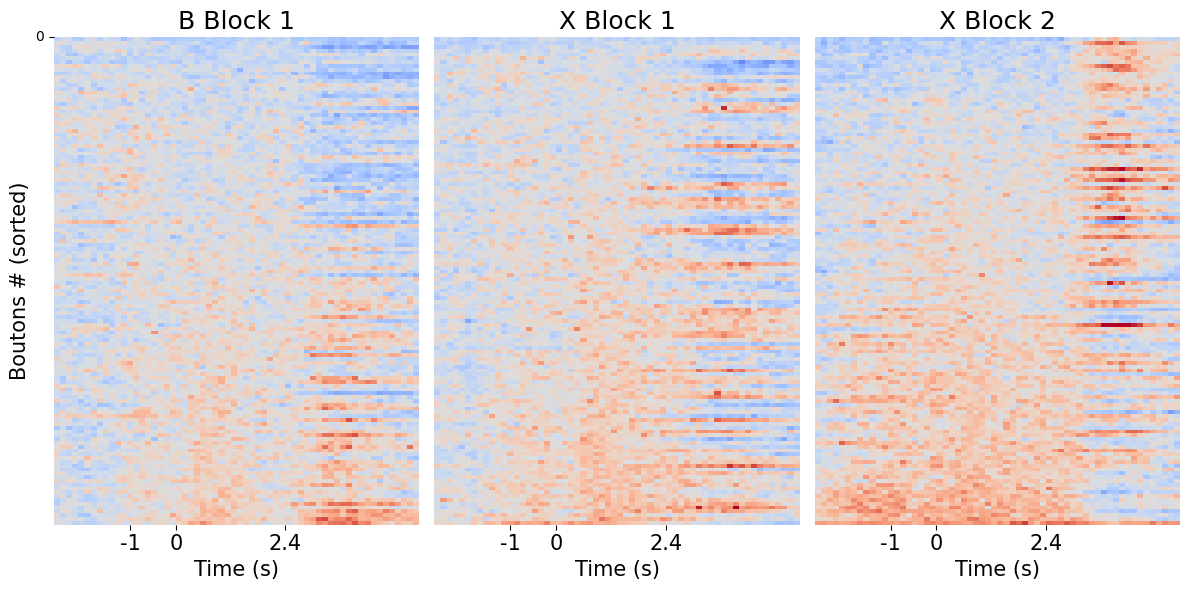

In [9]:
conditions = [
    {'type': 'predicted', 'activity': 'gr_2', 'title': 'B Block 1'},
    {'type': 'unpred', 'activity': 'gr_2', 'title': 'X Block 1'},
    {'type': 'unpred_late', 'activity': 'gr_2', 'title': 'X Block 2'}
]

plot_heatmaps(data, ani_range, conditions, poststim_frames, vmax=2, vmin=-2, max_tri = 15, sort_by='self', label='Boutons')

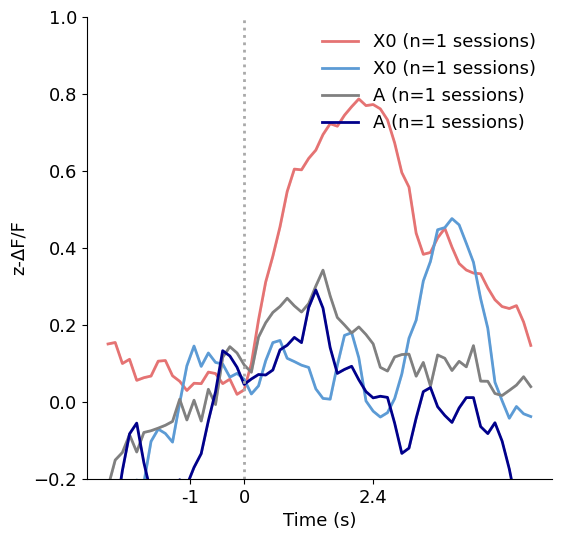

In [10]:
importlib.reload(viz)
max_tr = 5
conditions = [
    {'activity': 'gr_2', 'cells': 'X0', 'trials': 'gr_2', 'slice': slice(0,max_tr), 'color': '#E57373', 'label':'X0'},
    {'activity': 'gr_2', 'cells': 'X0', 'trials': 'gr_2', 'slice': slice(15,15+max_tr), 'color': '#5C9BD5', 'label':'X0'},
    {'activity': 'gr_1', 'cells': 'gr_1', 'trials': 'gr_2', 'slice': slice(0,max_tr), 'color': 'grey', 'label': 'A'},
    {'activity': 'gr_1', 'cells': 'gr_1', 'trials': 'gr_2', 'slice': slice(15,15+max_tr), 'color': 'darkblue', 'label': 'A'},
]

ani_range = [0]
importlib.reload(viz)
fig, axes = viz.plot_unexp_psth(data, sig_cells, ani_range, conditions, ylim=[-.2,1])
# fig, axes = viz.plot_unexp_psth_concat(data, sig_cells, ani_range, conditions, figsize=(6,6),ylim=[-.5,1])

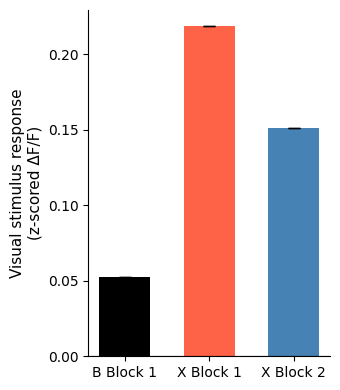

In [11]:
conditions = [
    {'type': 'predicted', 'activity': 'gr_2', 'title': 'B Block 1'},
    {'type': 'unpred', 'activity': 'gr_2', 'title': 'X Block 1'},
    {'type': 'unpred_late', 'activity': 'gr_2', 'title': 'X Block 2'}
]

fig, ax = plot_condition_barplot(data, ani_range, conditions, poststim_frames, max_tri = 5)

In [20]:
for num in np.array(sig_cells[ani]['X0']):
    if num in np.array(sig_cells[ani]['gr_2']):
        print(num)

19
20
26
31
38
79
95
99


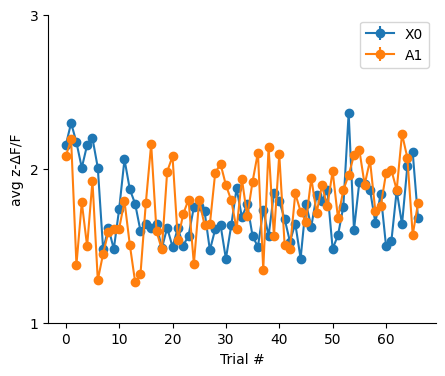

In [36]:
ctl =[0]
fig, axes = plt.subplots(1, 1, figsize=(5,4))
min_trials = min([len(data[ani]['unpred_trials']['gr_2']) for ani in ani_range])
x_vals = list(range(min_trials))
axes.set_ylabel('avg z-ΔF/F')

grat= 'gr_2'
poststim_frames = slice(23,33)
sal = []
for _,ani in enumerate(ctl):
    sal.append(np.mean(np.max(data[ani]['activity'][grat][sig_cells[ani]['X0']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
    # sal.append(np.mean(np.mean(data[ani]['activity'][grat][sig_cells[ani]['gr_2']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))

axes.errorbar(x_vals, np.mean(sal, axis=0),np.std(sal, axis=0) / np.sqrt(len(sal)),fmt='o-', color='#1f77b4', label='X0')

grat= 'gr_1'
poststim_frames = slice(23,33)
sal = []
for _,ani in enumerate(ctl):
    sal.append(np.mean(np.max(data[ani]['activity'][grat][sig_cells[ani]['gr_1']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
    # sal.append(np.mean(np.mean(data[ani]['activity'][grat][sig_cells[ani]['gr_1']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
axes.errorbar(x_vals, np.mean(sal, axis=0),np.std(sal, axis=0) / np.sqrt(len(sal)),fmt='o-', color='#ff7f0e', label='A1')

axes.set_yticks([1,2,3])
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_xlabel('Trial #')
axes.legend()

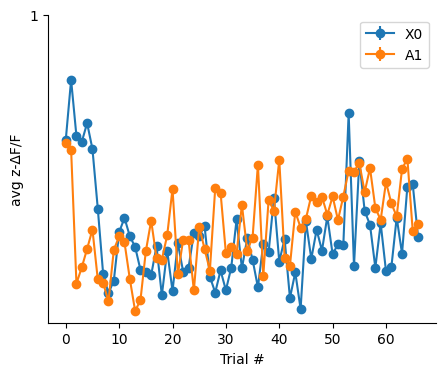

In [33]:
ctl =[0]
fig, axes = plt.subplots(1, 1, figsize=(5,4))
min_trials = min([len(data[ani]['unpred_trials']['gr_2']) for ani in ani_range])
x_vals = list(range(min_trials))
axes.set_ylabel('avg z-ΔF/F')

grat= 'gr_2'
poststim_frames = slice(23,33)
sal = []
for _,ani in enumerate(ctl):
    # sal.append(np.mean(np.max(data[ani]['activity'][grat][sig_cells[ani]['gr_1']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
    sal.append(np.mean(np.mean(data[ani]['activity'][grat][sig_cells[ani]['X0']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))

axes.errorbar(x_vals, np.mean(sal, axis=0),np.std(sal, axis=0) / np.sqrt(len(sal)),fmt='o-', color='#1f77b4', label='X0')

grat= 'gr_1'
poststim_frames = slice(23,33)
sal = []
for _,ani in enumerate(ctl):
    # sal.append(np.mean(np.max(data[ani]['activity'][grat][sig_cells[ani]['all']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
    sal.append(np.mean(np.mean(data[ani]['activity'][grat][sig_cells[ani]['gr_1']][:, data[ani]['unpred_trials']['gr_2'][:min_trials], poststim_frames], axis=2), axis=0))
axes.errorbar(x_vals, np.mean(sal, axis=0),np.std(sal, axis=0) / np.sqrt(len(sal)),fmt='o-', color='#ff7f0e', label='A1')

axes.set_yticks([1])
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_xlabel('Trial #')
axes.legend()